In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
from time import perf_counter

import numpy as np
import torch

import sys
sys.path.append("/content/drive/MyDrive/IDL 2026")
from matplotlib import pyplot as plt
from idl.common import  accuracy
from idl.week1.data import get_mnist, load_mnist, mnist_overview
from idl.week1.analysis import confusion_matrix, plot_learning_curves, precision_recall

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device is", DEVICE)

Device is cuda


In [4]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Converts images into PyTorch tensors
transform = transforms.ToTensor()

# Loads the training set of MNIST
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
# using the test set for validation
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# use the dataloader to load the and batch the train and validation sets
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [5]:
import torch.nn as nn

model = nn.Sequential(
    nn.Flatten(), # Turns each 28×28 image into one long list of 784 numbers
    nn.Linear(784, 256), # Takes 784 inputs (pixels) and converts them into 256 learned features
    nn.ReLU(), # Keeps positive values, removes negatives
    nn.Linear(256, 10) # Turns 256 features into 10 outputs
).to(DEVICE)

loss_fn = nn.CrossEntropyLoss() # This measures how wrong the predictions are
optimizer = torch.optim.SGD(model.parameters(), lr=0.1) # This updates the model weights after each batch
# as we see the coding is quite simpler with torch.nn

In [6]:
def train_mlp_model(model, train_loader, test_loader, loss_fn, optimizer, n_epochs, verbose=True):
    train_losses = []
    train_accuracies = []
    val_losses = []
    val_accuracies = []

    for epoch in range(n_epochs):
        if verbose:
            print("Starting epoch {}...".format(epoch + 1), end=" ")
        start_time = perf_counter()

        epoch_train_losses = []
        epoch_train_accuracies = []

        # DataLoader handles shuffling and batching for us now
        for input_batch, label_batch in train_loader:
            input_batch = input_batch.to(DEVICE)
            label_batch = label_batch.to(DEVICE)

            output_batch = model(input_batch)
            batch_loss = loss_fn(output_batch, label_batch)
            batch_loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            batch_accuracy = accuracy(output_batch, label_batch)
            epoch_train_losses.append(batch_loss.item())
            epoch_train_accuracies.append(batch_accuracy.item())

        end_time = perf_counter()

        # evaluate after each epoch
        with torch.no_grad():
            val_epoch_losses = []
            val_epoch_accuracies = []
            for val_inputs, val_labels in test_loader:
                val_inputs = val_inputs.to(DEVICE)
                val_labels = val_labels.to(DEVICE)
                val_output = model(val_inputs)
                val_epoch_losses.append(loss_fn(val_output, val_labels).item())
                val_epoch_accuracies.append(accuracy(val_output, val_labels).item())

        train_losses.append(np.mean(epoch_train_losses))
        train_accuracies.append(np.mean(epoch_train_accuracies))
        val_losses.append(np.mean(val_epoch_losses))
        val_accuracies.append(np.mean(val_epoch_accuracies))

        if verbose:
            print(f"Time taken: {end_time - start_time:.3f} seconds")
            print(f"\tTrain/val loss: {train_losses[-1]:.5g} / {val_losses[-1]:.5g}")
            print(f"\tTrain/val accuracy: {train_accuracies[-1]:.5g} / {val_accuracies[-1]:.5g}")
            print()

    return {"train_loss": np.array(train_losses), "train_accuracy": np.array(train_accuracies),
            "val_loss": np.array(val_losses), "val_accuracy": np.array(val_accuracies)}

In [7]:
metrics = train_mlp_model(model, train_loader, test_loader, loss_fn, optimizer, n_epochs=15)

Starting epoch 1... Time taken: 9.639 seconds
	Train/val loss: 0.56652 / 0.30636
	Train/val accuracy: 0.85914 / 0.91278

Starting epoch 2... Time taken: 8.703 seconds
	Train/val loss: 0.28754 / 0.24745
	Train/val accuracy: 0.91737 / 0.9283

Starting epoch 3... Time taken: 8.679 seconds
	Train/val loss: 0.23409 / 0.20398
	Train/val accuracy: 0.93372 / 0.94215

Starting epoch 4... Time taken: 7.747 seconds
	Train/val loss: 0.19736 / 0.17905
	Train/val accuracy: 0.94388 / 0.94818

Starting epoch 5... Time taken: 8.567 seconds
	Train/val loss: 0.16995 / 0.15701
	Train/val accuracy: 0.95191 / 0.9551

Starting epoch 6... Time taken: 8.716 seconds
	Train/val loss: 0.14859 / 0.14152
	Train/val accuracy: 0.95851 / 0.95985

Starting epoch 7... Time taken: 7.372 seconds
	Train/val loss: 0.13196 / 0.1291
	Train/val accuracy: 0.96301 / 0.96311

Starting epoch 8... Time taken: 8.330 seconds
	Train/val loss: 0.11845 / 0.11997
	Train/val accuracy: 0.96703 / 0.9645

Starting epoch 9... Time taken: 8.52

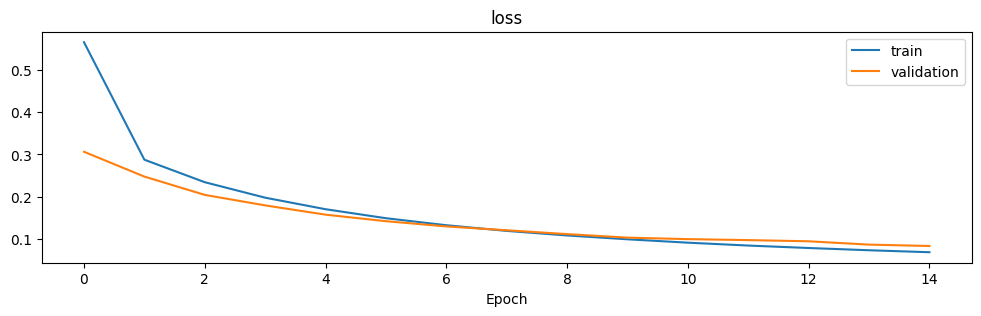

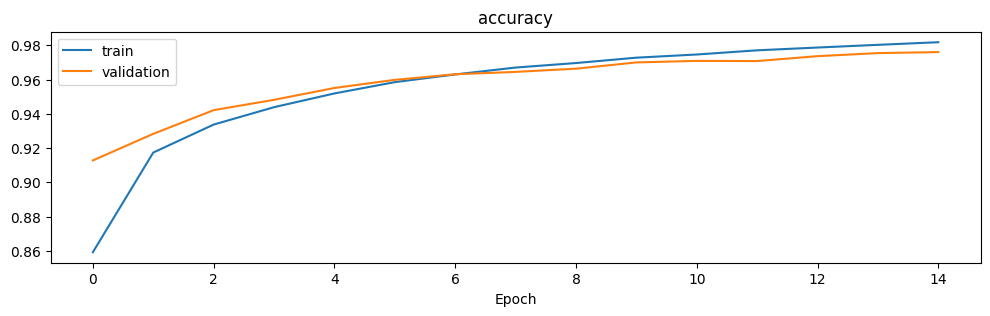

In [8]:
plot_learning_curves(metrics, keys=["loss", "accuracy"])

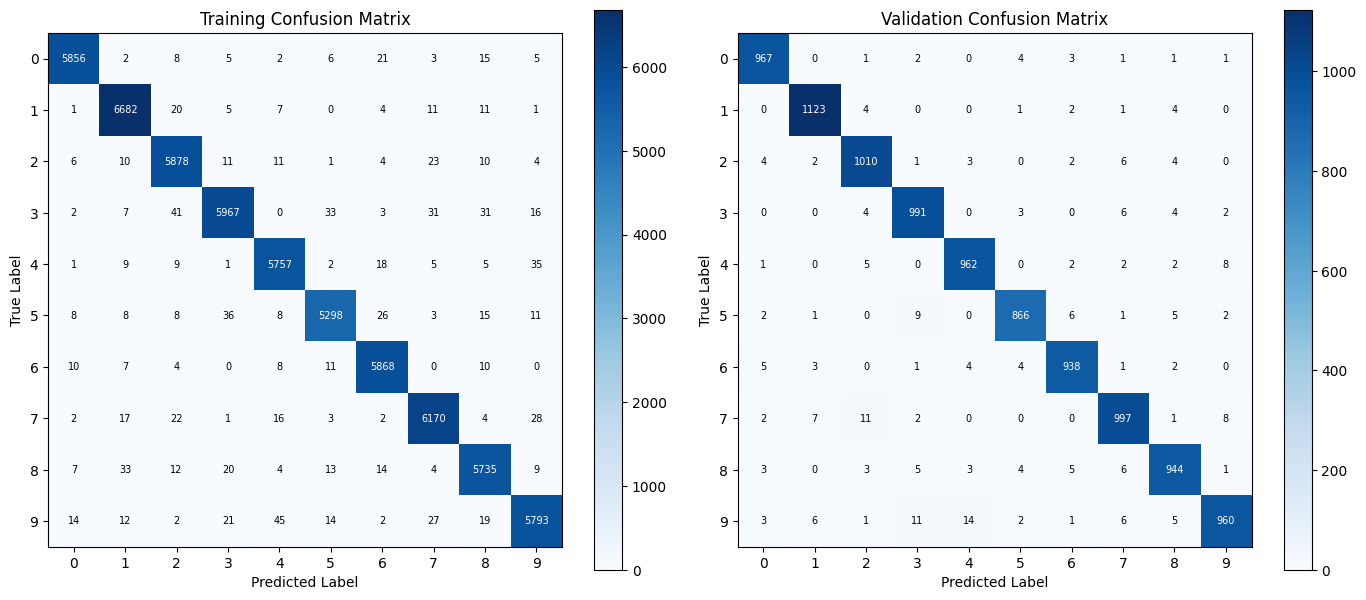

In [15]:
import matplotlib.pyplot as plt

training_matrix = confusion_matrix(model, train_dataset.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0, train_dataset.targets.numpy(), device=DEVICE)
validation_matrix = confusion_matrix(model, test_dataset.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0, test_dataset.targets.numpy(), device=DEVICE)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, matrix, title in zip(axes, [training_matrix, validation_matrix], ["Training Confusion Matrix", "Validation Confusion Matrix"]):
    im = ax.imshow(matrix, cmap="Blues")
    ax.set_title(title)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_xticks(np.arange(10))
    ax.set_yticks(np.arange(10))
    plt.colorbar(im, ax=ax)
    # add numbers inside each cell
    for i in range(10):
        for j in range(10):
            ax.text(j, i, str(matrix[i, j]), ha="center", va="center",
                    color="white" if matrix[i, j] > matrix.max() / 2 else "black", fontsize=7)

plt.tight_layout()
plt.show()

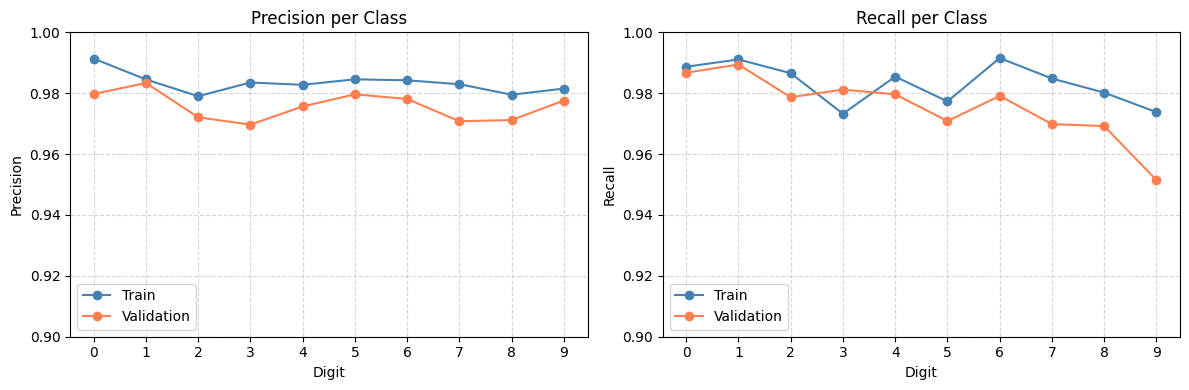

In [17]:
def get_precision_recall(matrix):
    precisions = []
    recalls = []
    for i in range(len(matrix)):
        tp = matrix[i, i]
        recall = tp / matrix[i].sum() if matrix[i].sum() > 0 else 0
        precision = tp / matrix[:, i].sum() if matrix[:, i].sum() > 0 else 0
        precisions.append(precision)
        recalls.append(recall)
    return np.array(precisions), np.array(recalls)

train_precision, train_recall = get_precision_recall(training_matrix)
val_precision, val_recall = get_precision_recall(validation_matrix)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(10), train_precision, marker='o', label="Train", color="steelblue")
axes[0].plot(range(10), val_precision, marker='o', label="Validation", color="coral")
axes[0].set_title("Precision per Class")
axes[0].set_xlabel("Digit")
axes[0].set_ylabel("Precision")
axes[0].set_xticks(range(10))
axes[0].set_ylim(0.9, 1.0)
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(range(10), train_recall, marker='o', label="Train", color="steelblue")
axes[1].plot(range(10), val_recall, marker='o', label="Validation", color="coral")
axes[1].set_title("Recall per Class")
axes[1].set_xlabel("Digit")
axes[1].set_ylabel("Recall")
axes[1].set_xticks(range(10))
axes[1].set_ylim(0.9, 1.0)
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

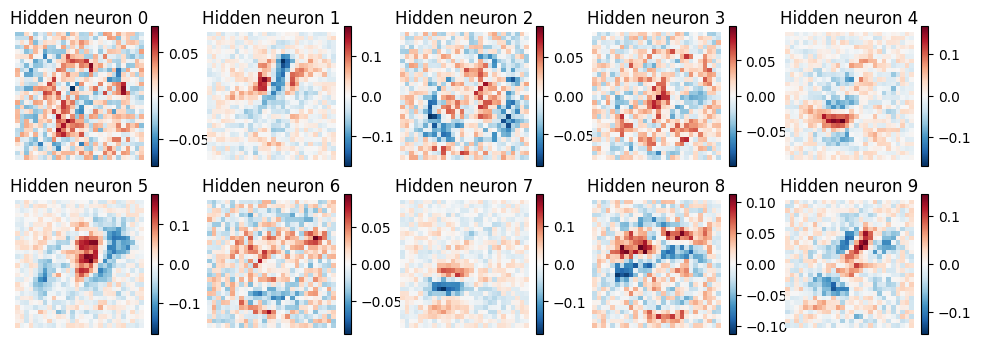

In [12]:
plt.figure(figsize=(12, 4))
for ind, pattern in enumerate(model[1].weight.detach().cpu().numpy()[:10]):  # [:10] limits to 10
    plt.subplot(2, 5, ind+1)
    absmax = abs(pattern).max()
    plt.imshow(pattern.reshape(28, 28), vmin=-absmax, vmax=absmax, cmap="RdBu_r")
    plt.axis("off")
    plt.colorbar()
    plt.title(f"Hidden neuron {ind}")
plt.show()

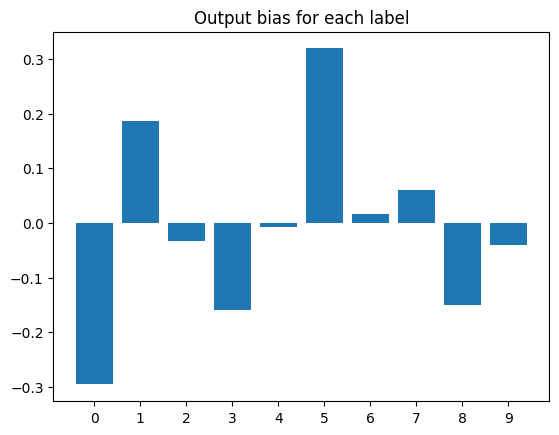

In [13]:
plt.bar(np.arange(10), model[3].bias.detach().cpu().numpy())
plt.xticks(np.arange(10))
plt.title("Output bias for each label")
plt.show()

Load FashionMNIST -  Here we train another model with FashionMNIST dataset

In [19]:
train_dataset_fashion = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset_fashion = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader_fashion = DataLoader(train_dataset_fashion, batch_size=128, shuffle=True)
test_loader_fashion = DataLoader(test_dataset_fashion, batch_size=128, shuffle=False)

100%|██████████| 26.4M/26.4M [00:00<00:00, 113MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 3.77MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 60.8MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 9.16MB/s]


In [20]:
model_fashion = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 256),
    nn.ReLU(),
    nn.Linear(256, 10)
).to(DEVICE)

optimizer_fashion = torch.optim.SGD(model_fashion.parameters(), lr=0.1)
metrics_fashion = train_mlp_model(model_fashion, train_loader_fashion, test_loader_fashion, loss_fn, optimizer_fashion, n_epochs=15)

Starting epoch 1... Time taken: 9.331 seconds
	Train/val loss: 0.72925 / 0.53694
	Train/val accuracy: 0.74835 / 0.81141

Starting epoch 2... Time taken: 8.509 seconds
	Train/val loss: 0.48734 / 0.4718
	Train/val accuracy: 0.82856 / 0.83258

Starting epoch 3... Time taken: 9.162 seconds
	Train/val loss: 0.43524 / 0.43712
	Train/val accuracy: 0.84701 / 0.84395

Starting epoch 4... Time taken: 8.901 seconds
	Train/val loss: 0.4029 / 0.41745
	Train/val accuracy: 0.8577 / 0.85265

Starting epoch 5... Time taken: 9.314 seconds
	Train/val loss: 0.38216 / 0.41674
	Train/val accuracy: 0.86395 / 0.85097

Starting epoch 6... Time taken: 10.848 seconds
	Train/val loss: 0.36572 / 0.39665
	Train/val accuracy: 0.87104 / 0.85522

Starting epoch 7... Time taken: 8.694 seconds
	Train/val loss: 0.35342 / 0.37705
	Train/val accuracy: 0.87418 / 0.86432

Starting epoch 8... Time taken: 10.624 seconds
	Train/val loss: 0.34072 / 0.38837
	Train/val accuracy: 0.87778 / 0.86214

Starting epoch 9... Time taken: 1

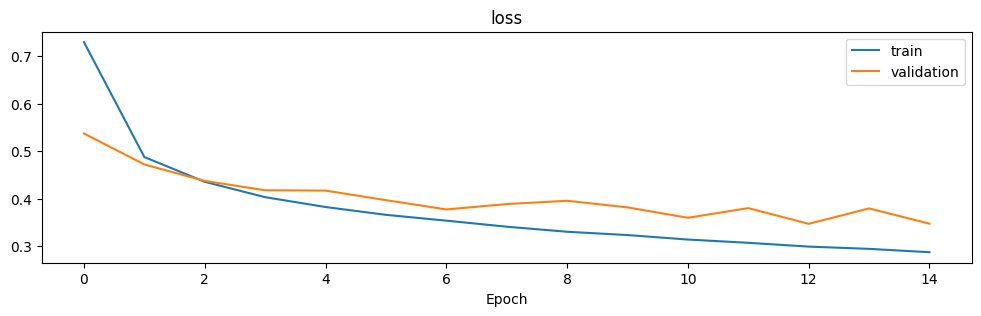

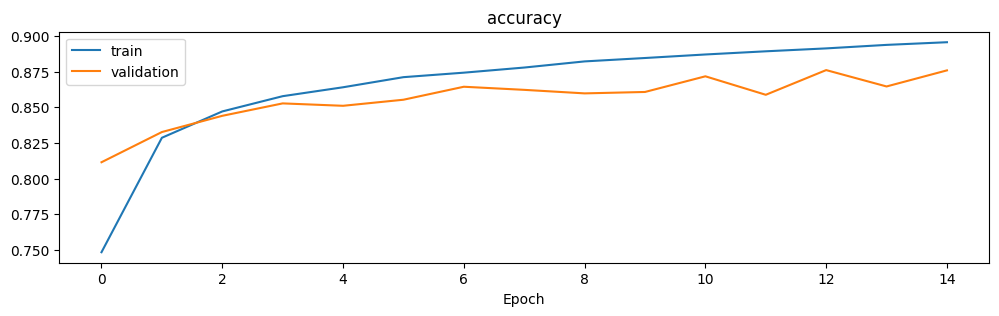

In [21]:
plot_learning_curves(metrics_fashion, keys=["loss", "accuracy"])

Epoch Benchmark




Starting epoch 1... Time taken: 8.792 seconds
	Train/val loss: 0.72366 / 0.53494
	Train/val accuracy: 0.75461 / 0.80894

Starting epoch 2... Time taken: 9.168 seconds
	Train/val loss: 0.48728 / 0.53336
	Train/val accuracy: 0.8297 / 0.804

Starting epoch 3... Time taken: 7.685 seconds
	Train/val loss: 0.43629 / 0.46272
	Train/val accuracy: 0.84555 / 0.83623

Starting epoch 4... Time taken: 8.571 seconds
	Train/val loss: 0.40574 / 0.43297
	Train/val accuracy: 0.85577 / 0.84029

Starting epoch 5... Time taken: 8.930 seconds
	Train/val loss: 0.38486 / 0.41417
	Train/val accuracy: 0.8631 / 0.85087

Epochs 5: final val accuracy = 0.8509
Starting epoch 1... Time taken: 8.087 seconds
	Train/val loss: 0.72124 / 0.54923
	Train/val accuracy: 0.75317 / 0.80409

Starting epoch 2... Time taken: 8.434 seconds
	Train/val loss: 0.4855 / 0.4665
	Train/val accuracy: 0.82999 / 0.83534

Starting epoch 3... Time taken: 8.781 seconds
	Train/val loss: 0.43421 / 0.45954
	Train/val accuracy: 0.84805 / 0.83317



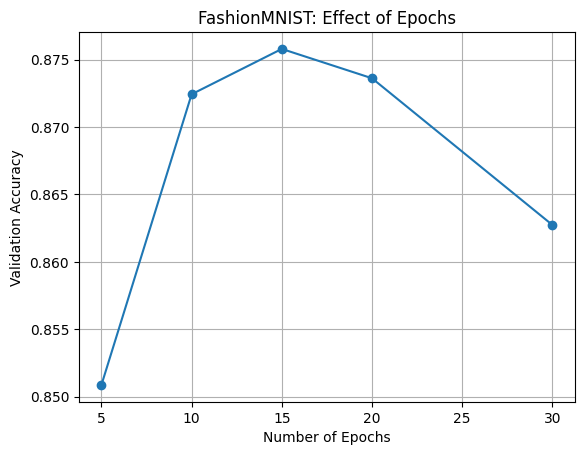

In [22]:
epoch_counts = [5, 10, 15, 20, 30]
epoch_results = {}

for n in epoch_counts:
    m = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 10)).to(DEVICE)
    opt = torch.optim.SGD(m.parameters(), lr=0.1)
    met = train_mlp_model(m, train_loader_fashion, test_loader_fashion, loss_fn, opt, n_epochs=n)
    epoch_results[n] = met['val_accuracy'][-1]
    print(f"Epochs {n}: final val accuracy = {epoch_results[n]:.4f}")

plt.plot(epoch_counts, list(epoch_results.values()), marker='o')
plt.xlabel("Number of Epochs")
plt.ylabel("Validation Accuracy")
plt.title("FashionMNIST: Effect of Epochs")
plt.grid(True)
plt.show()

We can see that peak accuracy is obtained at 15 epochs

Learning Rate Benchmark

Starting epoch 1... Time taken: 8.613 seconds
	Train/val loss: 2.2008 / 2.0904
	Train/val accuracy: 0.21304 / 0.3929

Starting epoch 2... Time taken: 8.356 seconds
	Train/val loss: 1.974 / 1.8607
	Train/val accuracy: 0.49294 / 0.56468

Starting epoch 3... Time taken: 10.187 seconds
	Train/val loss: 1.7419 / 1.6358
	Train/val accuracy: 0.60548 / 0.61837

Starting epoch 4... Time taken: 10.876 seconds
	Train/val loss: 1.5324 / 1.4477
	Train/val accuracy: 0.64106 / 0.643

Starting epoch 5... Time taken: 10.325 seconds
	Train/val loss: 1.3651 / 1.3031
	Train/val accuracy: 0.65449 / 0.65388

Starting epoch 6... Time taken: 8.662 seconds
	Train/val loss: 1.238 / 1.1937
	Train/val accuracy: 0.66308 / 0.65734

Starting epoch 7... Time taken: 7.975 seconds
	Train/val loss: 1.1415 / 1.1103
	Train/val accuracy: 0.66763 / 0.66139

Starting epoch 8... Time taken: 8.626 seconds
	Train/val loss: 1.067 / 1.0454
	Train/val accuracy: 0.67403 / 0.66545

Starting epoch 9... Time taken: 8.486 seconds
	Trai

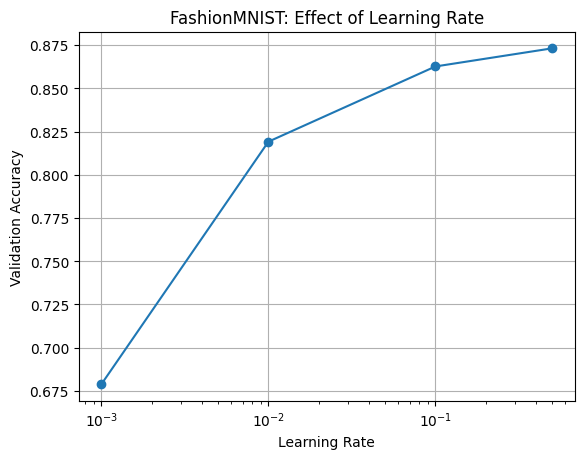

In [23]:
learning_rates = [0.001, 0.01, 0.1, 0.5]
lr_results = {}

for lr in learning_rates:
    m = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 10)).to(DEVICE)
    opt = torch.optim.SGD(m.parameters(), lr=lr)
    met = train_mlp_model(m, train_loader_fashion, test_loader_fashion, loss_fn, opt, n_epochs=10)
    lr_results[lr] = met['val_accuracy'][-1]
    print(f"Learning rate {lr}: final val accuracy = {lr_results[lr]:.4f}")

plt.plot(learning_rates, list(lr_results.values()), marker='o')
plt.xscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("Validation Accuracy")
plt.title("FashionMNIST: Effect of Learning Rate")
plt.grid(True)
plt.show()

The more we increase the learning rate we can see that the accuracy also increase finally achieving max value at 0.5 learning rate

Batch Size Benchmark

Starting epoch 1... Time taken: 10.559 seconds
	Train/val loss: 0.55602 / 0.44162
	Train/val accuracy: 0.80147 / 0.84125

Starting epoch 2... Time taken: 9.569 seconds
	Train/val loss: 0.40045 / 0.41271
	Train/val accuracy: 0.8549 / 0.85104

Starting epoch 3... Time taken: 10.583 seconds
	Train/val loss: 0.36183 / 0.38538
	Train/val accuracy: 0.86722 / 0.85853

Starting epoch 4... Time taken: 10.432 seconds
	Train/val loss: 0.337 / 0.36722
	Train/val accuracy: 0.87683 / 0.86991

Starting epoch 5... Time taken: 10.556 seconds
	Train/val loss: 0.32012 / 0.3709
	Train/val accuracy: 0.88172 / 0.86432

Starting epoch 6... Time taken: 10.427 seconds
	Train/val loss: 0.30292 / 0.37387
	Train/val accuracy: 0.88952 / 0.85873

Starting epoch 7... Time taken: 9.835 seconds
	Train/val loss: 0.29034 / 0.36269
	Train/val accuracy: 0.8927 / 0.86731

Starting epoch 8... Time taken: 9.862 seconds
	Train/val loss: 0.27936 / 0.33469
	Train/val accuracy: 0.89602 / 0.87999

Starting epoch 9... Time taken: 

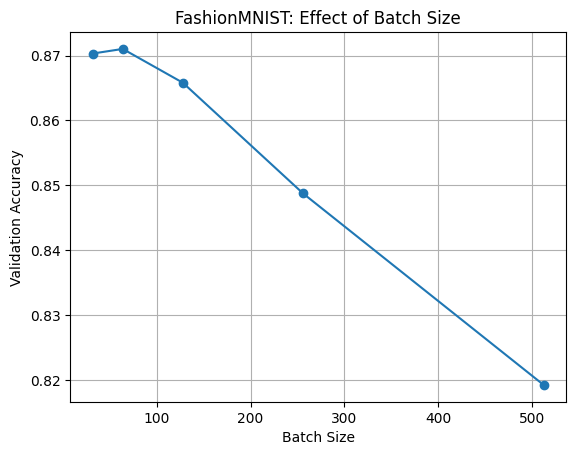

In [24]:
batch_sizes = [32, 64, 128, 256, 512]
batch_results = {}

for bs in batch_sizes:
    tl = DataLoader(train_dataset_fashion, batch_size=bs, shuffle=True)
    vl = DataLoader(test_dataset_fashion, batch_size=bs, shuffle=False)
    m = nn.Sequential(nn.Flatten(), nn.Linear(784, 256), nn.ReLU(), nn.Linear(256, 10)).to(DEVICE)
    opt = torch.optim.SGD(m.parameters(), lr=0.1)
    met = train_mlp_model(m, tl, vl, loss_fn, opt, n_epochs=10)
    batch_results[bs] = met['val_accuracy'][-1]
    print(f"Batch size {bs}: final val accuracy = {batch_results[bs]:.4f}")

plt.plot(batch_sizes, list(batch_results.values()), marker='o')
plt.xlabel("Batch Size")
plt.ylabel("Validation Accuracy")
plt.title("FashionMNIST: Effect of Batch Size")
plt.grid(True)
plt.show()

smaller batches give noisier but more frequent gradient updates which actually helps the model generalize better